<a href="https://colab.research.google.com/github/WebDeveloperDev/lunar_lander/blob/main/lunar_lander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install gymnasium
!pip install gymnasium[box2d]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 100.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 110.7 MB/s eta 0:00:00


In [6]:
import gymnasium as gym
import random
import numpy as np
from collections import deque
import os
import csv

import torch
import torch.nn as nn
import torch.optim as optim

Environment

In [30]:

env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5)

state_size = env.observation_space.shape[0] # x,y, velocity in x: x_dot,velocity in y:y_dot, theta, angular velocity: theta_dot, leg1_contact, leg2_contact
action_size = env.action_space.n # 0: do nothing, 1: fire left orientation engine, 2: fire main engine, 3: fire right orientation engine
print(f"State size: {state_size}, Action size: {action_size}")

State size: 8, Action size: 4


In [31]:
GAMMA = 0.99
LR = 0.0005
BATCH_SIZE = 64
MEMORY_SIZE = 50000

EPSILON = 1.0
EPSILON_MIN = 0.01
EPSILON_DECAY = 0.997

TARGET_UPDATE = 1000 #steps based not episode
EPISODES = 1000

In [32]:
memory = deque(maxlen=MEMORY_SIZE)

Network defination

In [33]:
class DQN(nn.Module):
    def __init__(self):
        super(DQN, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(state_size, 128),
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, action_size)
        )

    def forward(self, x):
        return self.net(x)

Network

In [34]:
policy_net = DQN()
target_net = DQN()

target_net.load_state_dict(policy_net.state_dict())

optimizer = optim.Adam(policy_net.parameters(), lr=LR)

Action Selection function

In [35]:
def select_action(state, epsilon):

    if random.random() < epsilon:
        return env.action_space.sample()

    state = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():
        q_values = policy_net(state)

    return q_values.argmax().item()


Training function

In [36]:
def train():

    if len(memory) < BATCH_SIZE:
        return

    batch = random.sample(memory, BATCH_SIZE)

    states, actions, rewards, next_states, dones = zip(*batch)

    states = torch.FloatTensor(states)
    actions = torch.LongTensor(actions).unsqueeze(1)
    rewards = torch.FloatTensor(rewards)
    next_states = torch.FloatTensor(next_states)
    dones = torch.FloatTensor(dones)

    # Current Q values
    current_q = policy_net(states).gather(1, actions).squeeze()

    # ==========================
    # DOUBLE DQN PART
    # ==========================

    # Policy network selects best actions
    next_actions = policy_net(next_states).argmax(1, keepdim=True)

    # Target network evaluates them
    next_q = target_net(next_states).gather(1, next_actions).squeeze()

    target_q = rewards + GAMMA * next_q * (1 - dones)

    # Loss
    loss = nn.MSELoss()(current_q, target_q.detach())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

Training LOOP

In [37]:
epsilon = EPSILON
# Files for metrics and model
metrics_file = "lunar_lander_training_metrics.csv"
model_path = "lunar_lander_ddqn_model.pth"

# In-memory buffers to avoid per-episode file I/O
episodes_buf = []
rewards_buf = []
epsilons_buf = []

for episode in range(EPISODES):

    state, _ = env.reset()
    total_reward = 0
    total_steps=0
    done = False

    while not done:

        action = select_action(state, epsilon)

        next_state, reward, terminated, truncated, _ = env.step(action)

        done = terminated or truncated


        memory.append((state, action, reward, next_state, done))

        state = next_state

        total_reward += reward

        train()
        if total_steps % TARGET_UPDATE == 0:
          target_net.load_state_dict(policy_net.state_dict())
        total_steps+=1

    # Update target network
    # if episode % TARGET_UPDATE == 0:
    #     target_net.load_state_dict(policy_net.state_dict())

    epsilon = max(EPSILON_MIN, epsilon * EPSILON_DECAY)

    print(f"Episode: {episode}, Reward: {total_reward}, Epsilon: {epsilon:.3f}")

    # Buffer metrics
    episodes_buf.append(episode)
    rewards_buf.append(total_reward)
    epsilons_buf.append(epsilon)

# Save final model
torch.save(policy_net.state_dict(), model_path)

# Write metrics once after training completes
with open(metrics_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["episode", "reward", "epsilon"])
    for e, r, eps in zip(episodes_buf, rewards_buf, epsilons_buf):
        writer.writerow([e, r, eps])

env.close()

Episode: 0, Reward: -274.89702480292374, Epsilon: 0.997
Episode: 1, Reward: -655.4517603184073, Epsilon: 0.994
Episode: 2, Reward: -255.75299178914014, Epsilon: 0.991
Episode: 3, Reward: -140.34225923370616, Epsilon: 0.988
Episode: 4, Reward: -154.04131660268212, Epsilon: 0.985
Episode: 5, Reward: -85.32119346465049, Epsilon: 0.982
Episode: 6, Reward: -313.3938324035554, Epsilon: 0.979
Episode: 7, Reward: -110.21987228905529, Epsilon: 0.976
Episode: 8, Reward: -101.3702692972553, Epsilon: 0.973
Episode: 9, Reward: -99.40650098706863, Epsilon: 0.970
Episode: 10, Reward: -85.95407559748561, Epsilon: 0.967
Episode: 11, Reward: -102.5413084599716, Epsilon: 0.965
Episode: 12, Reward: -96.74897789501665, Epsilon: 0.962
Episode: 13, Reward: -111.66366270642509, Epsilon: 0.959
Episode: 14, Reward: -112.56536581991806, Epsilon: 0.956
Episode: 15, Reward: -175.35004999172267, Epsilon: 0.953
Episode: 16, Reward: -69.88507947440627, Epsilon: 0.950
Episode: 17, Reward: -110.30754201779749, Epsilon:

Test Trained Model

In [38]:
import imageio
from IPython.display import Image

In [39]:
# =========================================================
# TEST TRAINED AGENT
# =========================================================

policy_net.load_state_dict(torch.load(model_path))
policy_net.eval()
test_env = gym.make("LunarLander-v3", render_mode="rgb_array")
frames = []

state, _ = test_env.reset()

done = False

total_reward = 0

while not done:
    frame = test_env.render()
    frames.append(frame)
    state_tensor = torch.FloatTensor(state).unsqueeze(0)

    with torch.no_grad():

        q_values = policy_net(state_tensor)

    action = torch.argmax(q_values).item()

    next_state, reward, terminated, truncated, _ = test_env.step(action)

    done = terminated or truncated

    state = next_state

    total_reward += reward
imageio.mimsave("lander.gif", frames, fps=30)

Image(filename="lander.gif")

print("\nTest Reward:", total_reward)


test_env.close()


Test Reward: 281.5786215941444


Visualize the  Training progress

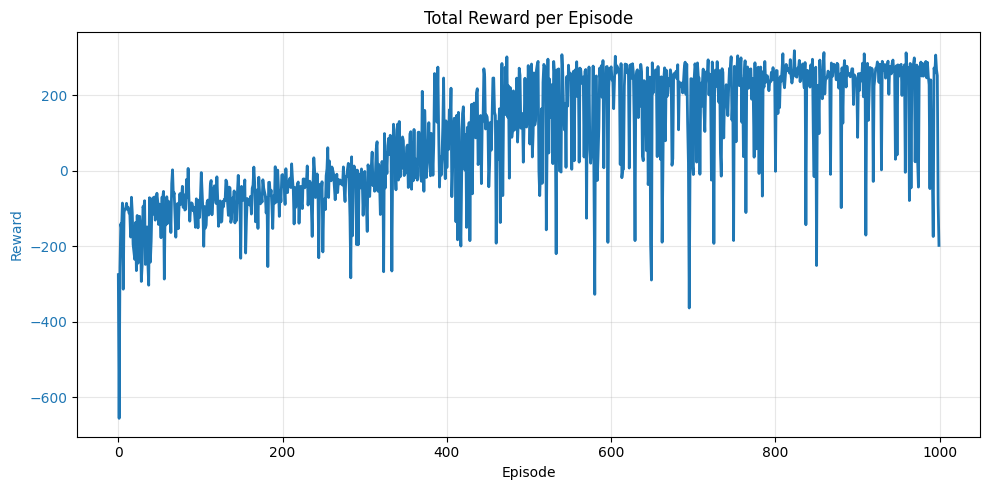

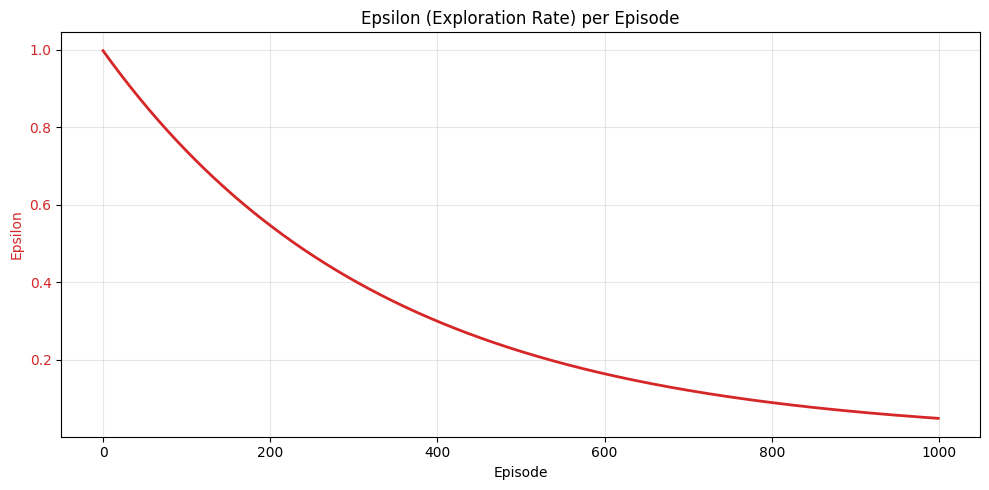

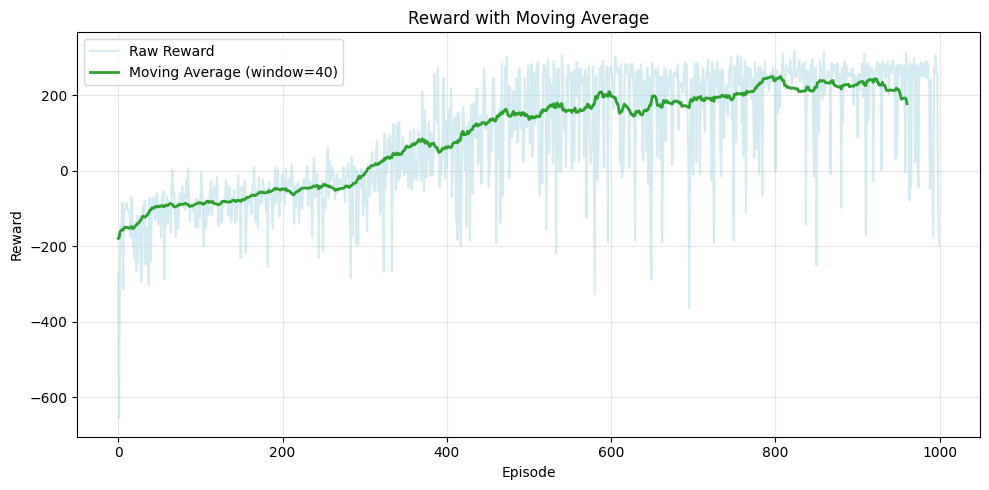

In [40]:
import matplotlib.pyplot as plt
import numpy as np

metrics_file = "lunar_lander_training_metrics.csv"
if os.path.exists(metrics_file):
    data = np.genfromtxt(metrics_file, delimiter=",", names=True)
    episodes = data['episode']
    rewards = data['reward']
    epsilons = data['epsilon']

    # Figure 1: Reward
    fig1, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(episodes, rewards, color='tab:blue', linewidth=2)
    ax1.set_xlabel('Episode')
    ax1.set_ylabel('Reward', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.set_title('Total Reward per Episode')
    ax1.grid(True, alpha=0.3)
    fig1.tight_layout()
    plt.show()

    # Figure 2: Epsilon
    fig2, ax2 = plt.subplots(figsize=(10, 5))
    ax2.plot(episodes, epsilons, color='tab:red', linewidth=2)
    ax2.set_xlabel('Episode')
    ax2.set_ylabel('Epsilon', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')
    ax2.set_title('Epsilon (Exploration Rate) per Episode')
    ax2.grid(True, alpha=0.3)
    fig2.tight_layout()
    plt.show()

    # Figure 3: Moving Average of Reward (window=40)
    window = 40
    moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
    episodes_avg = episodes[:len(moving_avg)]

    fig3, ax3 = plt.subplots(figsize=(10, 5))
    ax3.plot(episodes, rewards, color='lightblue', alpha=0.5, label='Raw Reward')
    ax3.plot(episodes_avg, moving_avg, color='tab:green', linewidth=2, label=f'Moving Average (window={window})')
    ax3.set_xlabel('Episode')
    ax3.set_ylabel('Reward')
    ax3.set_title('Reward with Moving Average')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    fig3.tight_layout()
    plt.show()
else:
    print(f"No metrics file found at {metrics_file}. Run training first.")